# Stellar Lightcurve Prediction — Attention LSTM

In [8]:
import sys
!{sys.executable} -m ensurepip --upgrade
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install numpy pandas matplotlib scikit-learn torch

Looking in links: c:\Users\Anvi\AppData\Local\Temp\tmp8g4tz1b3
     ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
     --- ------------------------------------ 0.1/1.8 MB 8.9 MB/s eta 0:00:01
     ------------ --------------------------- 0.6/1.8 MB 7.4 MB/s eta 0:00:01
     -------------------------- ------------- 1.2/1.8 MB 10.8 MB/s eta 0:00:01
     ----------------------------------- ---- 1.6/1.8 MB 10.3 MB/s eta 0:00:01
     ---------------------------------------- 1.8/1.8 MB 9.6 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 23.0.1
    Uninstalling pip-23.0.1:
      Successfully uninstalled pip-23.0.1


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------- ----------------------------- 3.4/12.9 MB 18.4 MB/s eta 0:00:01
   ------------ --------------------------- 3.9/12.9 MB 15.7 MB/s eta 0:00:01
   --------------- ------------------------ 5.0/12.9 MB 7.5 MB/s eta 0:00:02
   ------------------ --------------------- 6.0/12.9 MB 7.0 MB/s eta 0:00:01
   -------------------- ------------------- 6.6/12.9 MB 6.2 MB/s eta 0:00:02
   ---------------------- ----------------- 7.3/12.9 MB 5.7 MB/s eta 0:00:01
   ------------------------- -------------- 8.1/12.9 MB 5.5 MB/s eta 0:00:01
   ----------------------------- ---------- 9.4/12.9 MB 5.5 MB/s eta 0:00:01
   -------------------------------- ------- 10.5/12.9 MB 5.5 MB/s eta 0:00:01
   ------------------------------------ --- 11.8/12.9 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------  12.8/12.9 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 12.9/12.9 MB 5.5 MB/s  0:00:02
   

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [ ]:
#!pip install torch scikit-learn matplotlib numpy pandas

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
def generateRichStar(length=2500, basePeriod=50, secondaryPeriod=130,
                      transitPeriod=200, noiseLevel=0.1,
                      redNoisePhi=0.8, flareProbability=0.002, seed=None):

    if seed is not None:
        np.random.seed(seed)

    t = np.arange(length)

    pulsation1 = 0.8 * np.sin(2 * np.pi * t / basePeriod)
    pulsation2 = 0.4 * np.sin(2 * np.pi * t / secondaryPeriod)
    magneticCycle = 0.3 * np.sin(2 * np.pi * t / 900)

    transit = np.zeros(length)
    for center in range(0, length, transitPeriod):
        width = 6
        depth = np.random.uniform(0.3, 0.6)
        for i in range(-width, width):
            idx = center + i
            if 0 <= idx < length:
                transit[idx] -= depth * np.exp(-(i ** 2) / (2 * (width / 2) ** 2))
    flares = np.zeros(length)
    for i in range(length):
        if np.random.rand() < flareProbability:
            amp = np.random.uniform(0.5, 1.5)
            for j in range(15):
                if i + j < length:
                    flares[i + j] += amp * np.exp(-j / 4)

    whiteNoise = np.random.normal(0, noiseLevel, length)
    redNoise = np.zeros(length)
    for i in range(1, length):
        redNoise[i] = redNoisePhi * redNoise[i - 1] + whiteNoise[i]

    timeVaryingNoise = np.random.normal(0, noiseLevel * (1 + t / length), length)

    return (pulsation1 + pulsation2 + magneticCycle
            + transit + flares + redNoise + timeVaryingNoise)

In [15]:
def buildDataset(series, window):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i + window])
        y.append(series[i + window])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [16]:
class TemporalAttention(nn.Module):
    def __init__(self, hiddenDim):
        super().__init__()
        self.attn = nn.Linear(hiddenDim, 1)

    def forward(self, lstmOut):
        scores = self.attn(lstmOut).squeeze(-1)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        context = (weights * lstmOut).sum(dim=1)
        return context, weights.squeeze(-1)

In [17]:
class AttentionLSTM(nn.Module):
    def __init__(self, inputDim=1, hiddenDim=64, numLayers=2,
                 dropout=0.2, bidirectional=True):
        super().__init__()
        self.hiddenDim = hiddenDim
        self.bidirectional = bidirectional
        self.directions = 2 if bidirectional else 1

        self.lstm = nn.LSTM(
            input_size=inputDim,
            hidden_size=hiddenDim,
            num_layers=numLayers,
            batch_first=True,
            dropout=dropout if numLayers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        self.attention = TemporalAttention(hiddenDim * self.directions)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hiddenDim * self.directions, 1)

    def forward(self, x):
        lstmOut, _ = self.lstm(x)
        context, attn = self.attention(lstmOut)
        out = self.dropout(context)
        out = self.fc(out).squeeze(-1)
        return out, attn

In [ ]:
def trainModel(xTrain, yTrain, xVal, yVal,
               hiddenDim=64, numLayers=2, dropout=0.2,
               lr=1e-3, weightDecay=1e-4,
               epochs=80, batchSize=64, patience=10,
               device='cpu'):
    xt = torch.tensor(xTrain).unsqueeze(-1).to(device)
    yt = torch.tensor(yTrain).to(device)
    xv = torch.tensor(xVal).unsqueeze(-1).to(device)
    yv = torch.tensor(yVal).to(device)

    loader = DataLoader(TensorDataset(xt, yt), batch_size=batchSize, shuffle=True)

    model = AttentionLSTM(hiddenDim=hiddenDim, numLayers=numLayers, dropout=dropout).to(device)
    criterion = nn.MSELoss()
    optimiser = optim.AdamW(model.parameters(), lr=lr, weight_decay=weightDecay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, mode='min', factor=0.5, patience=5, min_lr=1e-5)

    trainLosses, valLosses = [], []
    bestVal, bestState, wait = np.inf, None, 0

    for epoch in range(epochs):
        model.train()
        epochLoss = 0.0
        for xb, yb in loader:
            optimiser.zero_grad()
            pred, _ = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimiser.step()
            epochLoss += loss.item() * len(yb)
        trainLosses.append(epochLoss / len(yTrain))

        model.eval()
        with torch.no_grad():
            vPred, _ = model(xv)
            vLoss = criterion(vPred, yv).item()
        valLosses.append(vLoss)
        scheduler.step(vLoss)

        if vLoss < bestVal - 1e-6:
            bestVal = vLoss
            bestState = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(bestState)
    return model, {'train': trainLosses, 'val': valLosses}

In [19]:
def evaluateModel(model, xTest, yTest, device='cpu'):
    model.eval()
    xt = torch.tensor(xTest).unsqueeze(-1).to(device)
    with torch.no_grad():
        preds, attn = model(xt)
    preds = preds.cpu().numpy()
    attn = attn.cpu().numpy()
    metrics = {
        'r2': r2_score(yTest, preds),
        'mse': mean_squared_error(yTest, preds),
        'mae': mean_absolute_error(yTest, preds),
    }
    return preds, attn, metrics

In [20]:
WINDOW_SIZES = [30, 80, 150]
NOISE_LEVELS = [0.05, 0.10, 0.20]
SEEDS = [0, 1, 2]

def runExperiments(seriesLength=2500, epochs=80, device='cpu'):
    results = {
        'r2': np.zeros((3, 3)),
        'mse': np.zeros((3, 3)),
        'mae': np.zeros((3, 3)),
    }
    lossCurves = []
    scaler = StandardScaler()

    for ni, noise in enumerate(NOISE_LEVELS):
        for wi, window in enumerate(WINDOW_SIZES):
            seedR2, seedMse, seedMae = [], [], []

            for seed in SEEDS:
                raw = generateRichStar(length=seriesLength, noiseLevel=noise, seed=seed)
                series = scaler.fit_transform(raw.reshape(-1, 1)).flatten().astype(np.float32)

                X, y = buildDataset(series, window)
                n = len(X)
                trainEnd = int(0.70 * n)
                valEnd = int(0.85 * n)
                xTr, yTr = X[:trainEnd], y[:trainEnd]
                xVl, yVl = X[trainEnd:valEnd], y[trainEnd:valEnd]
                xTe, yTe = X[valEnd:], y[valEnd:]

                torch.manual_seed(seed)
                model, history = trainModel(xTr, yTr, xVl, yVl, epochs=epochs, device=device)

                _, _, metrics = evaluateModel(model, xTe, yTe, device=device)
                seedR2.append(metrics['r2'])
                seedMse.append(metrics['mse'])
                seedMae.append(metrics['mae'])

                if ni == 0 and wi == 1:
                    lossCurves.append(history)

            results['r2'][ni, wi] = np.mean(seedR2)
            results['mse'][ni, wi] = np.mean(seedMse)
            results['mae'][ni, wi] = np.mean(seedMae)

            print(f"noise={noise:.2f} window={window:3d} "
                  f"R2={results['r2'][ni,wi]:.3f} "
                  f"MSE={results['mse'][ni,wi]:.4f} "
                  f"MAE={results['mae'][ni,wi]:.4f}")

    return results, lossCurves

In [21]:
def plotLightcurveDecomposition():
    np.random.seed(42)
    length = 600
    t = np.arange(length)
    p1 = 0.8 * np.sin(2 * np.pi * t / 50)
    p2 = 0.4 * np.sin(2 * np.pi * t / 130)
    mc = 0.3 * np.sin(2 * np.pi * t / 900)
    transit = np.zeros(length)
    for center in range(0, length, 200):
        w, d = 6, 0.45
        for i in range(-w, w):
            if 0 <= center + i < length:
                transit[center + i] -= d * np.exp(-(i ** 2) / (2 * (w / 2) ** 2))
    flares = np.zeros(length)
    for idx in [120, 280, 450]:
        for j in range(15):
            if idx + j < length:
                flares[idx + j] += 0.9 * np.exp(-j / 4)
    wn = np.random.normal(0, 0.1, length)
    rn = np.zeros(length)
    for i in range(1, length):
        rn[i] = 0.8 * rn[i - 1] + wn[i]
    composite = p1 + p2 + mc + transit + flares + rn

    components = [
        (composite, 'Composite light curve', '#2563EB', True),
        (p1 + p2 + mc, 'Pulsation', '#7C3AED', False),
        (transit, 'Transit signal', '#059669', False),
        (flares, 'Stellar flares', '#D97706', False),
        (rn, 'Red noise', '#6B7280', False),
    ]
    fig, axes = plt.subplots(len(components), 1, figsize=(14, 10), sharex=True)
    fig.suptitle('Synthetic stellar light curve decomposition', fontsize=14, fontweight='bold', y=1.01)
    for ax, (signal, label, color, bold) in zip(axes, components):
        ax.plot(t, signal, color=color, linewidth=1.4 if bold else 0.9)
        ax.set_ylabel(label, fontsize=9, labelpad=4)
        ax.tick_params(labelsize=8)
        ax.spines[['top', 'right']].set_visible(False)
        if bold:
            ax.set_facecolor('#F8FAFC')
    axes[-1].set_xlabel('Time step', fontsize=10)
    plt.tight_layout()
    plt.savefig('fig1_lightcurve_decomposition.png', dpi=150, bbox_inches='tight')
    plt.show()

In [22]:
def plotNoiseComparison():
    np.random.seed(0)
    fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
    fig.suptitle('Effect of noise level on synthetic light curve', fontsize=13, fontweight='bold')
    colors = ['#1D9E75', '#EF9F27', '#D85A30']
    for ax, noise, color in zip(axes, NOISE_LEVELS, colors):
        star = generateRichStar(length=600, noiseLevel=noise)
        ax.plot(star, color=color, linewidth=0.8)
        ax.set_ylabel(f'sigma = {noise}', fontsize=10)
        ax.tick_params(labelsize=8)
        ax.spines[['top', 'right']].set_visible(False)
    axes[-1].set_xlabel('Time step', fontsize=10)
    plt.tight_layout()
    plt.savefig('fig2_noise_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

In [23]:
def plotWindowIllustration():
    np.random.seed(1)
    series = generateRichStar(length=300, noiseLevel=0.05)
    scaler = StandardScaler()
    series = scaler.fit_transform(series.reshape(-1, 1)).flatten()
    t, start = np.arange(len(series)), 50

    fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
    fig.suptitle('Sliding window sizes on a normalised light curve', fontsize=13, fontweight='bold')
    colors = ['#7C3AED', '#2563EB', '#059669']
    for ax, window, color in zip(axes, WINDOW_SIZES, colors):
        ax.plot(t, series, color='#9CA3AF', linewidth=0.7, zorder=1)
        ax.axvspan(start, start + window, alpha=0.25, color=color, label=f'Window w={window}')
        ax.axvline(start + window, color=color, linewidth=1.5, linestyle='--', label='Target y', zorder=3)
        ax.scatter([start + window], [series[start + window]], color=color, s=50, zorder=4)
        ax.set_ylabel(f'w = {window}', fontsize=10)
        ax.tick_params(labelsize=8)
        ax.legend(fontsize=8, loc='upper right')
        ax.spines[['top', 'right']].set_visible(False)
    axes[-1].set_xlabel('Time step', fontsize=10)
    plt.tight_layout()
    plt.savefig('fig3_window_illustration.png', dpi=150, bbox_inches='tight')
    plt.show()

In [24]:
def plotResultsHeatmaps(results):
    metrics = [results['r2'], results['mse'], results['mae']]
    titles = ['R2 (higher is better)', 'MSE (lower is better)', 'MAE (lower is better)']
    cmaps = ['RdYlGn', 'RdYlGn_r', 'RdYlGn_r']

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    fig.suptitle('Attention-LSTM 3x3 experiment grid (mean over 3 seeds)', fontsize=13, fontweight='bold')
    for ax, data, title, cmap in zip(axes, metrics, titles, cmaps):
        im = ax.imshow(data, cmap=cmap, aspect='auto', vmin=data.min() * 0.9, vmax=data.max() * 1.05)
        ax.set_xticks(range(3))
        ax.set_xticklabels([f'w={w}' for w in WINDOW_SIZES], fontsize=9)
        ax.set_yticks(range(3))
        ax.set_yticklabels([f's={n}' for n in NOISE_LEVELS], fontsize=9)
        ax.set_title(title, fontsize=10, pad=8)
        rng = data.max() - data.min() or 1.0
        for i in range(3):
            for j in range(3):
                rel = (data[i, j] - data.min()) / rng
                ax.text(j, i, f'{data[i,j]:.3f}', ha='center', va='center',
                        fontsize=10, fontweight='bold',
                        color='white' if rel < 0.4 else '#1a1a1a')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig('fig4_results_heatmaps.png', dpi=150, bbox_inches='tight')
    plt.show()

In [25]:
def plotR2Trends(results):
    R2 = results['r2']
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('R2 trends Attention-LSTM (mean over 3 seeds)', fontsize=13, fontweight='bold')
    colors = ['#1D9E75', '#EF9F27', '#D85A30']
    markers = ['o', 's', '^']

    ax = axes[0]
    for i, (noise, color, marker) in enumerate(zip(NOISE_LEVELS, colors, markers)):
        ax.plot(WINDOW_SIZES, R2[i], color=color, marker=marker, linewidth=2, markersize=7, label=f's={noise}')
    ax.set_xlabel('Window size', fontsize=10)
    ax.set_ylabel('R2', fontsize=10)
    ax.set_title('R2 vs window size', fontsize=11)
    ax.set_xticks(WINDOW_SIZES)
    ax.legend(fontsize=9)
    ax.set_ylim(0.2, 1.0)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

    ax = axes[1]
    winColors = ['#7C3AED', '#2563EB', '#059669']
    for j, (window, color, marker) in enumerate(zip(WINDOW_SIZES, winColors, markers)):
        ax.plot(NOISE_LEVELS, R2[:, j], color=color, marker=marker, linewidth=2, markersize=7, label=f'w={window}')
    ax.set_xlabel('Noise level (sigma)', fontsize=10)
    ax.set_ylabel('R2', fontsize=10)
    ax.set_title('R2 vs noise level', fontsize=11)
    ax.set_xticks(NOISE_LEVELS)
    ax.legend(fontsize=9)
    ax.set_ylim(0.2, 1.0)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('fig5_r2_trends.png', dpi=150, bbox_inches='tight')
    plt.show()

In [26]:
def plotGroupedBars(results):
    x = np.arange(3)
    width = 0.25
    colors = ['#7C3AED', '#2563EB', '#059669']
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    fig.suptitle('Metric breakdown all 9 conditions (mean over 3 seeds)', fontsize=13, fontweight='bold')
    dataSets = [
        (results['r2'], 'R2', True),
        (results['mse'], 'MSE', False),
        (results['mae'], 'MAE', False),
    ]
    for ax, (data, ylabel, higherBetter) in zip(axes, dataSets):
        for j, (window, color) in enumerate(zip(WINDOW_SIZES, colors)):
            ax.bar(x + j * width, data[:, j], width, label=f'w={window}',
                   color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
        ax.set_xticks(x + width)
        ax.set_xticklabels([f's={n}' for n in NOISE_LEVELS], fontsize=9)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(f'{ylabel} ({"up" if higherBetter else "down"} better)', fontsize=11)
        ax.legend(fontsize=8)
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('fig6_grouped_bars.png', dpi=150, bbox_inches='tight')
    plt.show()

In [27]:
def plotPredVsTrue(results):
    np.random.seed(7)
    n = 400
    bestR2 = results['r2'].max()
    midR2 = float(np.median(results['r2']))
    worstR2 = results['r2'].min()

    def simulate(r2):
        true = np.random.randn(n)
        std = np.sqrt(max((1 - r2) / r2, 1e-6)) * true.std()
        pred = true + np.random.normal(0, std, n)
        return true, pred

    conditions = [
        (bestR2, f'Best R2={bestR2:.2f}', '#1D9E75'),
        (midR2, f'Median R2={midR2:.2f}', '#EF9F27'),
        (worstR2, f'Worst R2={worstR2:.2f}', '#D85A30'),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
    fig.suptitle('Predicted vs true flux (normalised units)', fontsize=13, fontweight='bold')
    for ax, (r2, label, color) in zip(axes, conditions):
        true, pred = simulate(r2)
        ax.scatter(true, pred, alpha=0.3, s=10, color=color)
        lim = max(abs(true).max(), abs(pred).max()) * 1.05
        ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=1, alpha=0.5)
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_xlabel('True', fontsize=9)
        ax.set_ylabel('Predicted', fontsize=9)
        ax.set_title(label, fontsize=9)
        ax.set_aspect('equal')
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=8)
    plt.tight_layout()
    plt.savefig('fig7_pred_vs_true.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
def plotValidationLossCurves(lossCurves):
    fig, axes = plt.subplots(1, len(lossCurves) + 1, figsize=(5 * (len(lossCurves) + 1), 4))
    fig.suptitle('Training and validation loss best condition (sigma=0.05, w=80)', fontsize=13, fontweight='bold')
    allVal = []
    seedColors = ['#7C3AED', '#2563EB', '#059669']
    for idx, (history, color) in enumerate(zip(lossCurves, seedColors)):
        tr, vl = history['train'], history['val']
        ax = axes[idx]
        epochs = range(1, len(tr) + 1)
        ax.plot(epochs, tr, color=color, linewidth=1.5, label='Train loss')
        ax.plot(epochs, vl, color=color, linewidth=1.5, linestyle='--', label='Val loss', alpha=0.8)
        ax.fill_between(epochs, tr, vl, alpha=0.08, color=color)
        ax.set_title(f'Seed {idx}', fontsize=10)
        ax.set_xlabel('Epoch', fontsize=9)
        ax.set_ylabel('MSE loss', fontsize=9)
        ax.legend(fontsize=8)
        ax.tick_params(labelsize=8)
        ax.spines[['top', 'right']].set_visible(False)
        allVal.append(vl)
    maxLen = max(len(v) for v in allVal)
    padded = [v + [v[-1]] * (maxLen - len(v)) for v in allVal]
    meanVal = np.mean(padded, axis=0)
    stdVal = np.std(padded, axis=0)
    ax = axes[-1]
    ep = range(1, maxLen + 1)
    ax.plot(ep, meanVal, color='#D85A30', linewidth=2, label='Mean val loss')
    ax.fill_between(ep, meanVal - stdVal, meanVal + stdVal, alpha=0.2, color='#D85A30', label='+-1 std')
    ax.set_title('Mean +- std across seeds', fontsize=10)
    ax.set_xlabel('Epoch', fontsize=9)
    ax.set_ylabel('MSE loss', fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('fig8_validation_loss_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
def plotAttentionHeatmap(device='cpu'):
    np.random.seed(0)
    torch.manual_seed(0)
    window = 80
    raw = generateRichStar(length=2500, noiseLevel=0.05, seed=0)
    scaler = StandardScaler()
    series = scaler.fit_transform(raw.reshape(-1, 1)).flatten().astype(np.float32)
    X, y = buildDataset(series, window)
    n = len(X)
    trainEnd = int(0.70 * n)
    valEnd = int(0.85 * n)
    model, _ = trainModel(
        X[:trainEnd], y[:trainEnd],
        X[trainEnd:valEnd], y[trainEnd:valEnd],
        epochs=60, device=device)
    xTest = X[valEnd:]
    xt = torch.tensor(xTest[:50]).unsqueeze(-1).to(device)
    model.eval()
    with torch.no_grad():
        _, attn = model(xt)
    meanAttn = attn.cpu().numpy().mean(axis=0)
    fig, axes = plt.subplots(2, 1, figsize=(12, 5), gridspec_kw={'height_ratios': [1, 3]})
    fig.suptitle('Temporal attention weights mean over 50 test samples\n(sigma=0.05, w=80, Attention-LSTM)',
                 fontsize=12, fontweight='bold')
    ax0 = axes[0]
    ax0.bar(range(window), meanAttn, color='#7C3AED', alpha=0.8, width=1.0)
    ax0.set_ylabel('Attention\nweight', fontsize=8)
    ax0.set_xlim(0, window)
    ax0.tick_params(labelsize=7)
    ax0.spines[['top', 'right']].set_visible(False)
    ax1 = axes[1]
    im = ax1.imshow(attn.cpu().numpy(), aspect='auto', cmap='plasma', origin='lower')
    ax1.set_xlabel('Window position (lag)', fontsize=9)
    ax1.set_ylabel('Test sample index', fontsize=9)
    plt.colorbar(im, ax=ax1, fraction=0.02, pad=0.02, label='Attention weight')
    ax1.tick_params(labelsize=8)
    plt.tight_layout()
    plt.savefig('fig9_attention_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

In [30]:
def exportResultsToCsv(results):
    rows = []
    for ni, noise in enumerate(NOISE_LEVELS):
        for wi, window in enumerate(WINDOW_SIZES):
            rows.append({
                'noiseLevel': float(noise),
                'windowSize': int(window),
                'r2': float(results['r2'][ni, wi]),
                'mse': float(results['mse'][ni, wi]),
                'mae': float(results['mae'][ni, wi]),
            })
    pd.DataFrame(rows).to_csv('experiment_results.csv', index=False)
    print("Saved -> experiment_results.csv")

Device: cpu


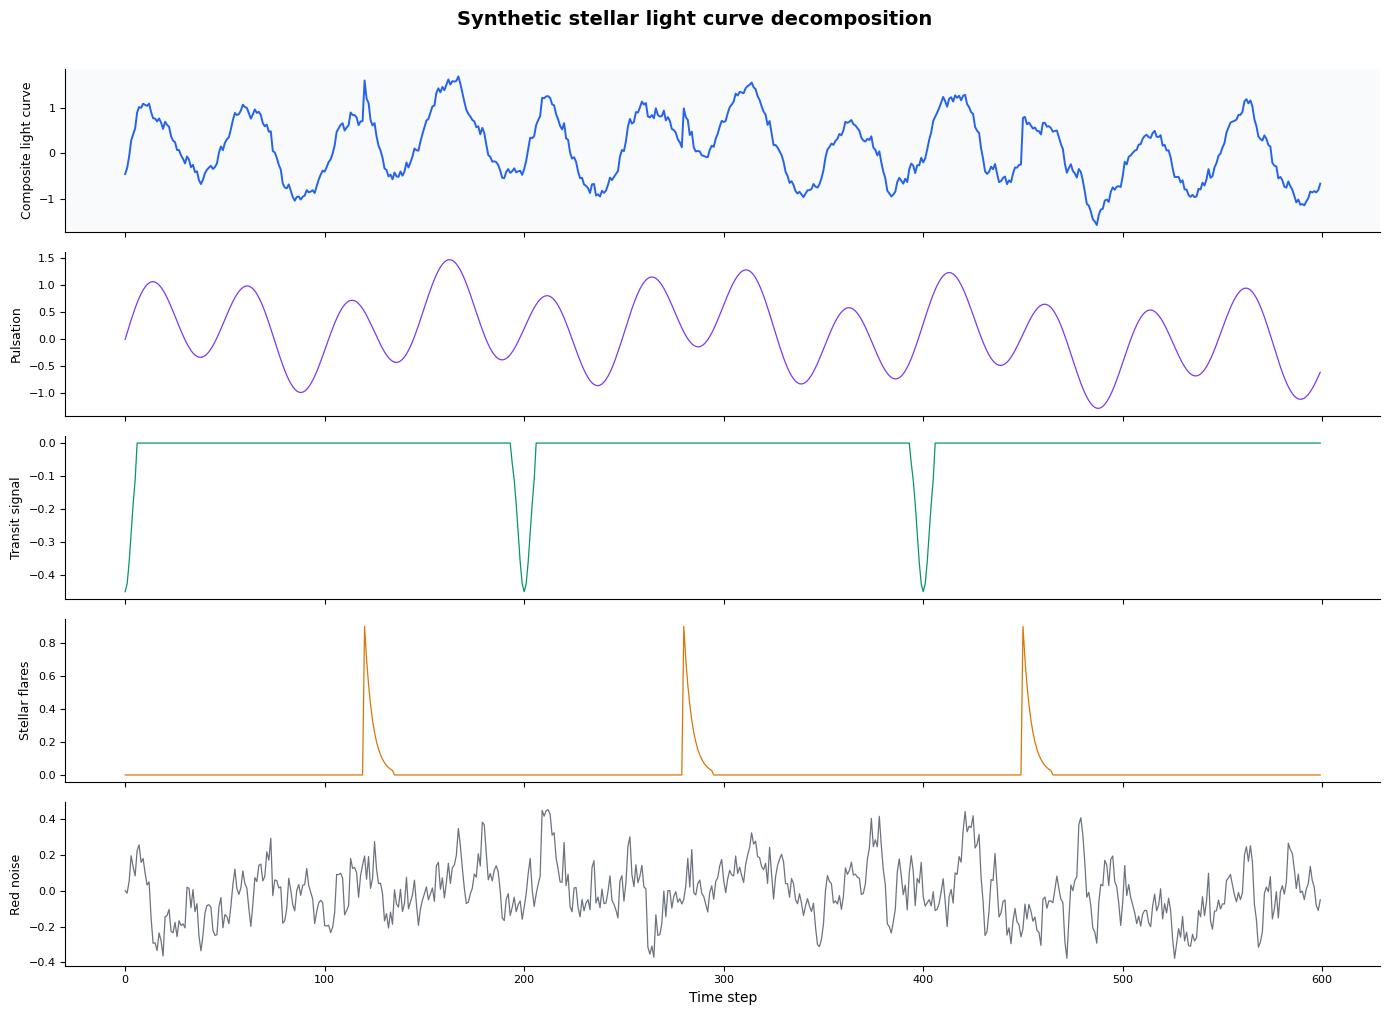

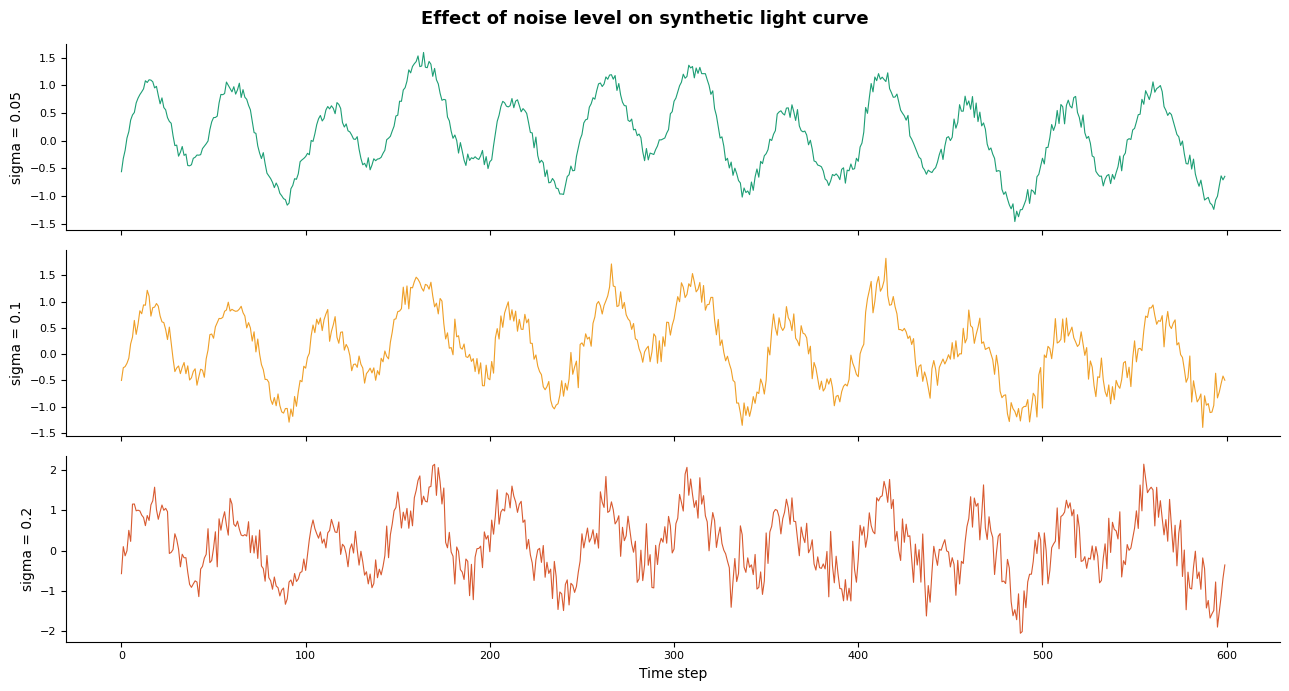

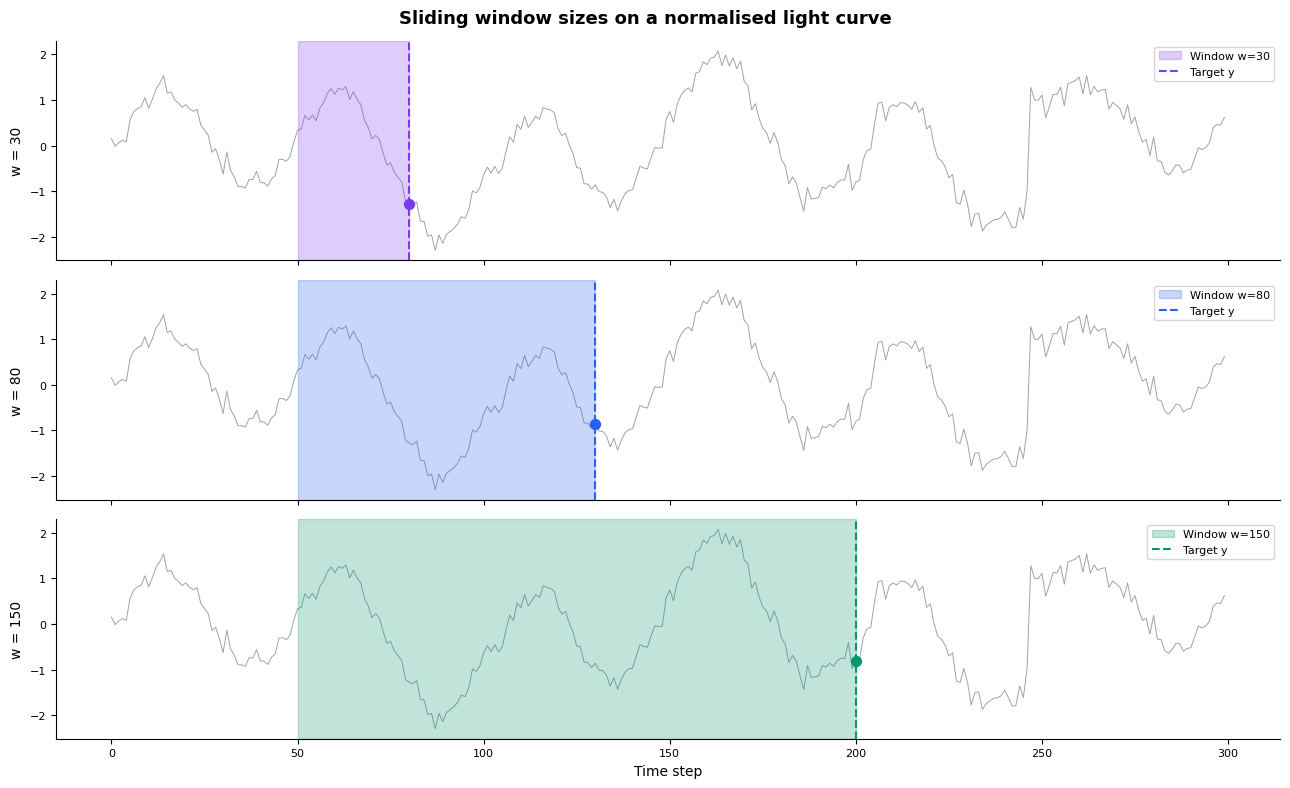

noise=0.05 window= 30 R2=0.954 MSE=0.0412 MAE=0.1609
noise=0.05 window= 80 R2=0.949 MSE=0.0462 MAE=0.1707
noise=0.05 window=150 R2=0.958 MSE=0.0390 MAE=0.1555
noise=0.10 window= 30 R2=0.864 MSE=0.1277 MAE=0.2842
noise=0.10 window= 80 R2=0.873 MSE=0.1201 MAE=0.2762
noise=0.10 window=150 R2=0.871 MSE=0.1249 MAE=0.2804
noise=0.20 window= 30 R2=0.654 MSE=0.3617 MAE=0.4785
noise=0.20 window= 80 R2=0.656 MSE=0.3598 MAE=0.4766
noise=0.20 window=150 R2=0.672 MSE=0.3477 MAE=0.4695


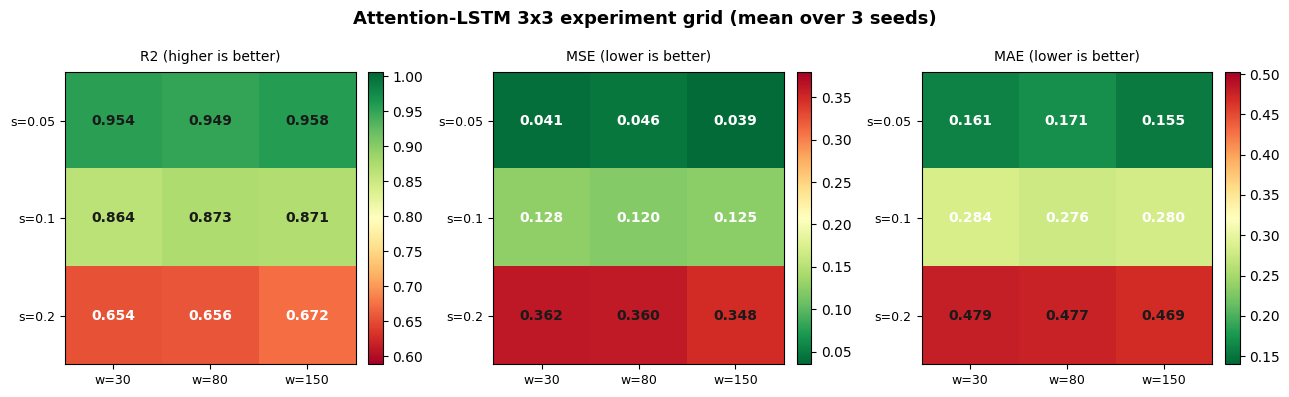

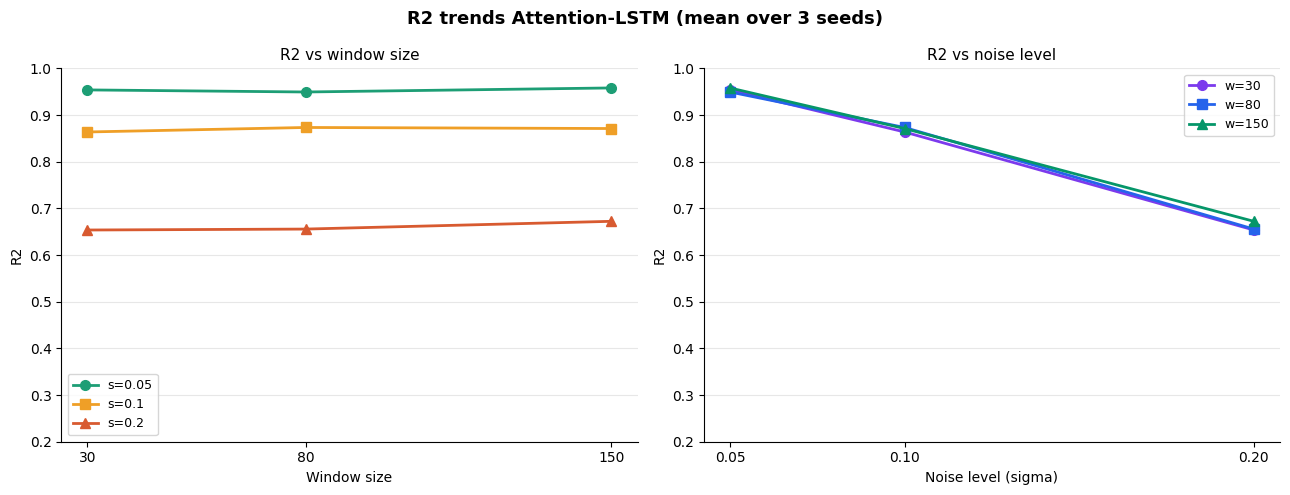

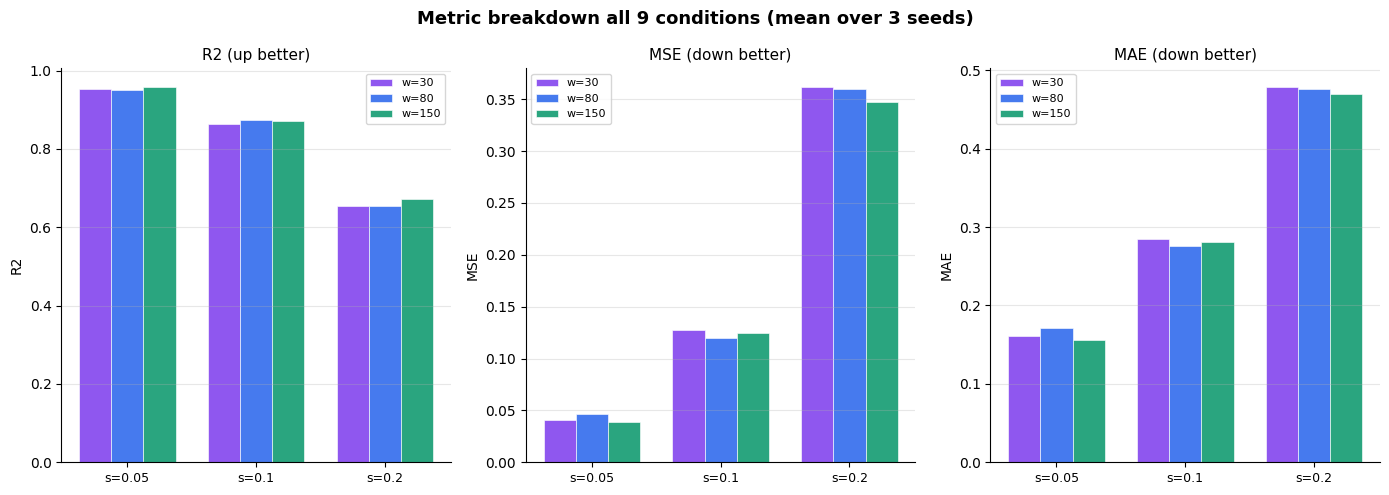

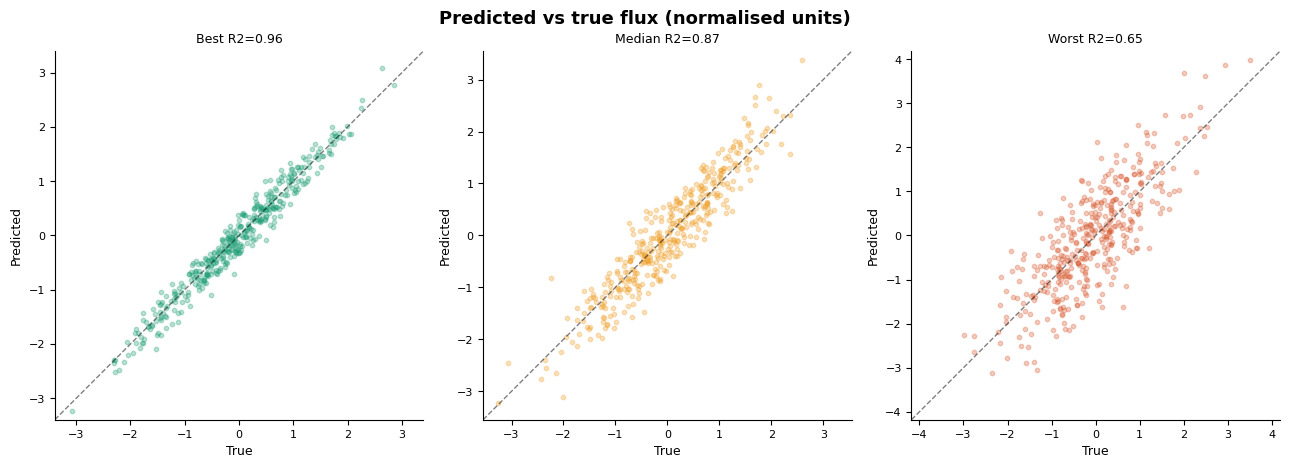

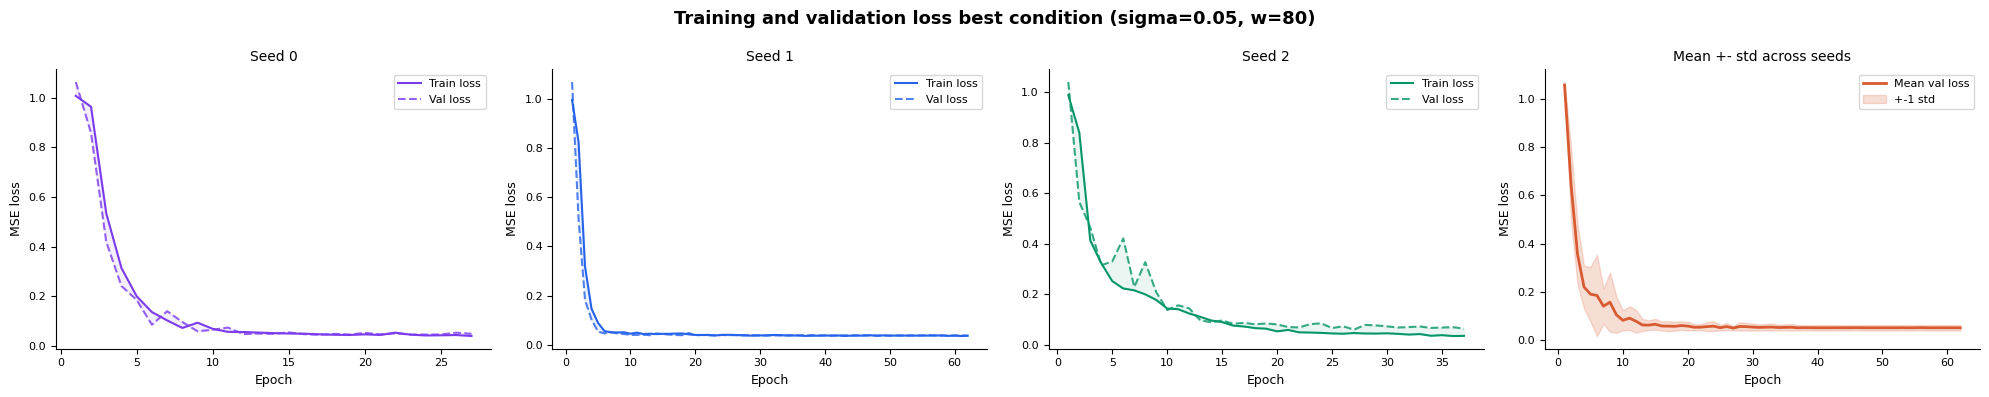

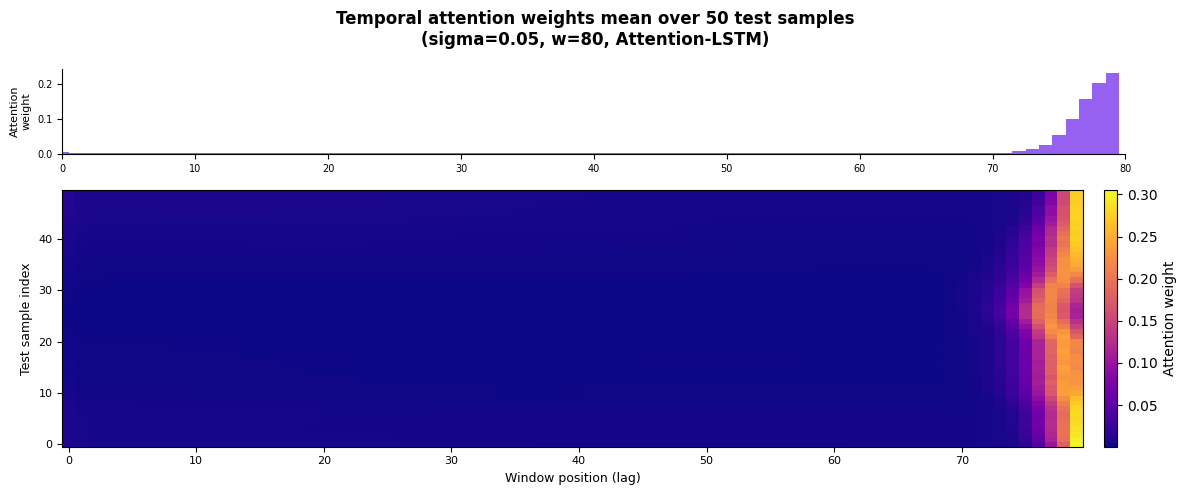

Saved -> experiment_results.csv
Done.


In [31]:
if __name__ == '__main__':
    runtimeDevice = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Device: {runtimeDevice}")
    plotLightcurveDecomposition()
    plotNoiseComparison()
    plotWindowIllustration()
    experimentResults, experimentLossCurves = runExperiments(seriesLength=2500, epochs=80, device=runtimeDevice)
    plotResultsHeatmaps(experimentResults)
    plotR2Trends(experimentResults)
    plotGroupedBars(experimentResults)
    plotPredVsTrue(experimentResults)
    plotValidationLossCurves(experimentLossCurves)
    plotAttentionHeatmap(device=runtimeDevice)
    exportResultsToCsv(experimentResults)

    print("Done.")